# Ablation Study — Interações entre Componentes

**Experimentos:** I1 (\(\lambda\) × estimador de volatilidade) · I2 (\(\gamma_{\text{risk}}\) × \(\gamma_{\text{trade}}\))

Este notebook existe porque ablações marginais (um fator por vez) podem **errar o mecanismo** quando há complementaridade/substituição entre componentes.

- **Interação (conceito):** existe interação quando o efeito de um fator sobre a métrica muda dependendo do nível do outro fator. Em notação de regressão, isso aparece como um termo \(x_1\times x_2\) diferente de zero.

## I1 — \(\lambda\) × estimador de volatilidade (Stage 1)
**Pergunta:** o ganho do estimador Yang–Zhang (menor ruído/maior eficiência) é maior quando \(\lambda\) é baixo (modelo mais flexível)?

## I2 — \(\gamma_{\text{risk}}\) × \(\gamma_{\text{trade}}\) (Stage 3)
**Pergunta:** o “melhor” \(\gamma_{\text{trade}}\) depende do budget de risco \(\gamma_{\text{risk}}\)? Em outras palavras, fricção e agressividade **se compensam** ou **se reforçam**?

### Protocolo experimental
- **Fatorial parcial:** 3 × 3 = 9 configurações por interação
- **Agregação:** média sobre ativos × seeds
- **Visualização:** heatmap + interaction plot (linhas não paralelas sugerem interação)
- **Interpretação:** interação *complementar* quando uma combinação específica domina além do esperado por aditividade

In [1]:
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import time
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from tqdm.notebook import tqdm

from src.data.loader import DataLoader
from src.data.preprocessor import DataPreprocessor
from src.config.settings import (
    ASSETS, TEST_START, TEST_END,
    ASSET_TICKERS, DATA_START, DATA_END, FRED_SERIES,
)

from src.ablation.ablation_runner import (
    run_single_ablation, prepare_ablation_data,
    ABLATION_I1_CONFIGS, ABLATION_I2_CONFIGS,
)
from src.ablation.statistical_tests import wilcoxon_test, cohens_d
from src.ablation.polars_utils import float_nan_to_null

plt.style.use('seaborn-v0_8-whitegrid')
print('✓ Imports concluídos')

✓ Imports concluídos


In [2]:
loader = DataLoader(cache_dir=str(ROOT / 'data' / 'raw'))
prices = loader.load_prices(ASSET_TICKERS, start=DATA_START, end=DATA_END)
fred_raw = loader.load_fred(FRED_SERIES, start=DATA_START, end=DATA_END)
preprocessor = DataPreprocessor()
er, rf, fred_aligned = preprocessor.prepare(prices, fred_raw)

DEMO_ASSETS = ASSETS
N_SEEDS = 20

features_cache = {}
vol_cache = {}
true_regimes_cache = {}

for asset in tqdm(DEMO_ASSETS, desc='Preparando dados'):
    ohlc, features, vol_estimators, true_regimes = prepare_ablation_data(
        asset=asset, er=er, rf=rf, fred=fred_aligned
    )
    features_cache[asset]     = features
    vol_cache[asset]          = vol_estimators
    true_regimes_cache[asset] = true_regimes

print('✓ Dados prontos')

Preparando dados:   0%|          | 0/12 [00:00<?, ?it/s]

✓ Dados prontos


## 1. Interação I1 — \(\lambda\) × estimador de volatilidade

### Mecanismo (por que deveria interagir)
- \(\lambda\) (jump penalty) controla quão “caro” é mudar de regime: \(\lambda\) baixo \(\) mais mudanças (maior sensibilidade), \(\lambda\) alto \(\) regimes mais estáveis.
- O estimador de volatilidade entra como feature/escala para o clustering; estimadores mais eficientes (p.ex., Yang–Zhang) tendem a reduzir ruído de microestrutura.

Se \(\lambda\) é baixo, o modelo está mais propenso a reagir a ruído — então **a qualidade do estimador pode importar mais**. Se \(\lambda\) é alto, a penalização já força estabilidade, e o ganho marginal do estimador pode diminuir.

**Grid 3×3:** \(\lambda \in \{25, 50, 100\}\) × estimador \(\in\) {Close-to-Close, Parkinson, Yang–Zhang}

In [3]:
I1_RESULTS_RAW = []

print(f'Ablation I1: {len(ABLATION_I1_CONFIGS)} configs × {len(DEMO_ASSETS)} ativos × {N_SEEDS} seeds')
t0 = time.time()

for asset in tqdm(DEMO_ASSETS, desc='Assets'):
    for config in tqdm(ABLATION_I1_CONFIGS, desc=f'I1 ({asset})', leave=False):
        for seed in range(N_SEEDS):
            res = run_single_ablation(
                config         = config,
                asset          = asset,
                er             = er,
                rf             = rf,
                features       = features_cache[asset],
                vol_estimators = vol_cache[asset],
                true_regimes   = true_regimes_cache[asset],
                seed           = seed,
            )
            row = res.to_dict()
            row['lambda_val'] = config.lambda_penalty
            row['estimator']  = config.vol_estimator
            I1_RESULTS_RAW.append(row)

I1_DF = float_nan_to_null(pl.DataFrame(I1_RESULTS_RAW))
print(f'✓ I1 concluído em {time.time() - t0:.1f}s')

Ablation I1: 9 configs × 12 ativos × 20 seeds


Assets:   0%|          | 0/12 [00:00<?, ?it/s]

I1 (LargeCap):   0%|          | 0/9 [00:00<?, ?it/s]

I1 (MidCap):   0%|          | 0/9 [00:00<?, ?it/s]

I1 (SmallCap):   0%|          | 0/9 [00:00<?, ?it/s]

...

I1 (Corporate):   0%|          | 0/9 [00:00<?, ?it/s]

I1 (REIT):   0%|          | 0/9 [00:00<?, ?it/s]

I1 (Commodity):   0%|          | 0/9 [00:00<?, ?it/s]

I1 (Gold):   0%|          | 0/9 [00:00<?, ?it/s]

✓ I1 concluído em 10943.9s


Tabela I1: ADD médio (λ × Estimador)
               CC  Parkinson  Yang-Zhang
lambda_val                              
25.0        27.48      28.47       28.92
50.0        35.63      36.92       36.00
100.0       41.85      41.79       41.96


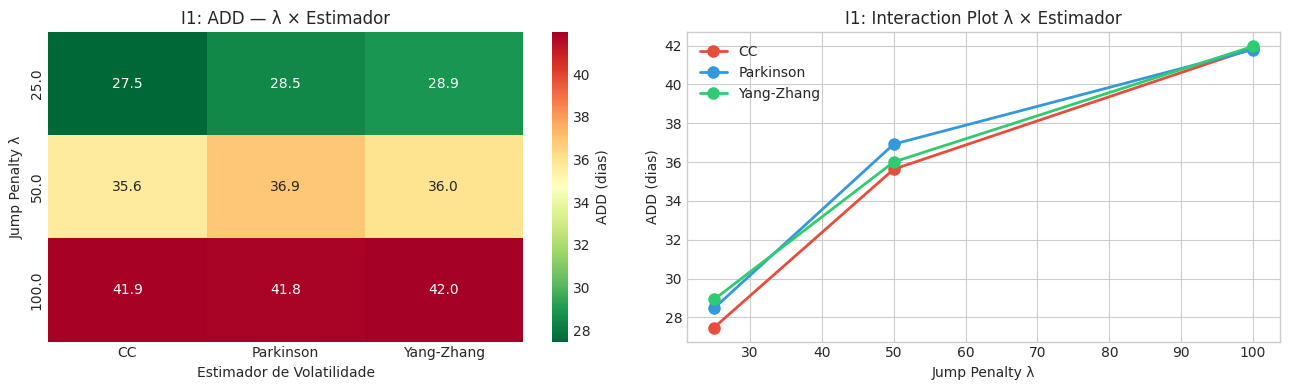


Benefício do Yang-Zhang vs. CC (ADD reduzido) por λ:
lambda_val
25.0    -1.44
50.0    -0.37
100.0   -0.10
Name: YZ_benefit_dias, dtype: float64


In [4]:
# Pivot: λ × estimador → ADD médio
I1_PIVOT = (
    I1_DF
    .group_by(['lambda_val', 'estimator'])
    .agg(pl.col('add').mean().alias('ADD_mean'))
    .to_pandas()
    .pivot(index='lambda_val', columns='estimator', values='ADD_mean')
    .sort_index()
)

# Mantém apenas os 3 estimadores do grid I1
est_cols = [c for c in ['close_to_close', 'parkinson', 'yang_zhang'] if c in I1_PIVOT.columns]
I1_PIVOT = I1_PIVOT[est_cols]
I1_PIVOT.columns = ['CC', 'Parkinson', 'Yang-Zhang'][:len(est_cols)]

print('Tabela I1: ADD médio (λ × Estimador)')
print(I1_PIVOT.round(2))

# Heatmap de interação
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Heatmap
sns.heatmap(
    I1_PIVOT.astype(float), annot=True, fmt='.1f', cmap='RdYlGn_r',
    ax=axes[0], cbar_kws={'label': 'ADD (dias)'},
    xticklabels=I1_PIVOT.columns, yticklabels=I1_PIVOT.index,
)
axes[0].set_xlabel('Estimador de Volatilidade')
axes[0].set_ylabel('Jump Penalty λ')
axes[0].set_title('I1: ADD — λ × Estimador')

# Interaction plot
colors_i1 = {'CC': '#e74c3c', 'Parkinson': '#3498db', 'Yang-Zhang': '#2ecc71'}
for col in I1_PIVOT.columns:
    axes[1].plot(I1_PIVOT.index, I1_PIVOT[col], 'o-',
                label=col, color=colors_i1.get(col, 'gray'), linewidth=2, markersize=8)
axes[1].set_xlabel('Jump Penalty λ')
axes[1].set_ylabel('ADD (dias)')
axes[1].set_title('I1: Interaction Plot λ × Estimador')
axes[1].legend()

plt.tight_layout()
plt.savefig(ROOT / 'results' / 'ablation_I1_interaction.png', dpi=150, bbox_inches='tight')
plt.show()

# Interpreta interação: o benefício do YZ é maior para λ baixo?
if 'CC' in I1_PIVOT.columns and 'Yang-Zhang' in I1_PIVOT.columns:
    yz_benefit = I1_PIVOT['CC'] - I1_PIVOT['Yang-Zhang']  # positivo = YZ é melhor
    print('\nBenefício do Yang-Zhang vs. CC (ADD reduzido) por λ:')
    print(yz_benefit.rename('YZ_benefit_dias').round(2))

## 2. Interação I2 — \(\gamma_{\text{risk}}\) × \(\gamma_{\text{trade}}\)

### Mecanismo (por que deveria interagir)
- \(\gamma_{\text{risk}}\) controla **exposição** em bull (agressividade): menor \(\gamma_{\text{risk}}\) \(\) mais risco/retorno; maior \(\gamma_{\text{risk}}\) \(\) estratégia mais conservadora.
- \(\gamma_{\text{trade}}\) controla **churn**: penaliza trocas e reduz turnover/custos.

A hipótese natural de interação é que o custo de churn cresce com a agressividade: quando a estratégia toma mais exposição, mudanças de posição “pesam” mais no PnL líquido. Então o \(\gamma_{\text{trade}}\) ótimo pode depender de \(\gamma_{\text{risk}}\).

**Grid 3×3:** \(\gamma_{\text{risk}} \in \{5, 10, 20\}\) × \(\gamma_{\text{trade}} \in \{0, 1, 2\}\)

In [ ]:
I2_RESULTS_RAW = []

print(f'Ablation I2: {len(ABLATION_I2_CONFIGS)} configs × {len(DEMO_ASSETS)} ativos × {N_SEEDS} seeds')
t0 = time.time()

for asset in tqdm(DEMO_ASSETS, desc='Assets'):
    for config in tqdm(ABLATION_I2_CONFIGS, desc=f'I2 ({asset})', leave=False):
        for seed in range(N_SEEDS):
            res = run_single_ablation(
                config         = config,
                asset          = asset,
                er             = er,
                rf             = rf,
                features       = features_cache[asset],
                vol_estimators = vol_cache[asset],
                true_regimes   = true_regimes_cache[asset],
                seed           = seed,
            )
            row = res.to_dict()
            row['gamma_risk']  = config.gamma_risk
            row['gamma_trade'] = config.gamma_trade
            I2_RESULTS_RAW.append(row)

I2_DF = float_nan_to_null(pl.DataFrame(I2_RESULTS_RAW))
print(f'✓ I2 concluído em {time.time() - t0:.1f}s')

Ablation I2: 9 configs × 12 ativos × 20 seeds


Assets:   0%|          | 0/12 [00:00<?, ?it/s]

I2 (LargeCap):   0%|          | 0/9 [00:00<?, ?it/s]

I2 (MidCap):   0%|          | 0/9 [00:00<?, ?it/s]

In [ ]:
# Pivot: γ_risk × γ_trade → Sortino médio
I2_PIVOT = (
    I2_DF
    .group_by(['gamma_risk', 'gamma_trade'])
    .agg(pl.col('sortino_ratio').mean().alias('Sortino_mean'))
    .to_pandas()
    .pivot(index='gamma_risk', columns='gamma_trade', values='Sortino_mean')
    .sort_index()
)

print('Tabela I2: Sortino Ratio (γ_risk × γ_trade)')
print(I2_PIVOT.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Heatmap Sortino
sns.heatmap(
    I2_PIVOT.astype(float), annot=True, fmt='.2f', cmap='RdYlGn',
    ax=axes[0], cbar_kws={'label': 'Sortino Ratio'},
    xticklabels=[f'γ_t={c}' for c in I2_PIVOT.columns],
    yticklabels=[f'γ_r={r}' for r in I2_PIVOT.index],
)
axes[0].set_xlabel('Trade Aversion γ_trade')
axes[0].set_ylabel('Risk Aversion γ_risk')
axes[0].set_title('I2: Sortino — γ_risk × γ_trade')

# Interaction plot
colors_gr = {5.0: '#e74c3c', 10.0: '#3498db', 20.0: '#2ecc71'}
for gr in I2_PIVOT.index:
    axes[1].plot(
        I2_PIVOT.columns, I2_PIVOT.loc[gr],
        'o-', label=f'γ_risk={gr:.0f}',
        color=colors_gr.get(gr, 'gray'), linewidth=2, markersize=8,
    )
axes[1].set_xlabel('Trade Aversion γ_trade')
axes[1].set_ylabel('Sortino Ratio')
axes[1].set_title('I2: Interaction Plot γ_risk × γ_trade')
axes[1].legend()

plt.tight_layout()
plt.savefig(ROOT / 'results' / 'ablation_I2_interaction.png', dpi=150, bbox_inches='tight')
plt.show()

# Encontra combinação ótima
_st = I2_PIVOT.stack(dropna=False).dropna()
if len(_st):
    opt_idx = _st.idxmax()
    opt_sortino = float(_st.max())
    print(f'\nCombinação ótima: γ_risk={opt_idx[0]}, γ_trade={opt_idx[1]}')
    print(f'  Sortino: {opt_sortino:.3f}')
else:
    print('\n⚠ Sortino médio indefinido para todas as células do grid I2.')

In [ ]:
# Salva resultados
results_dir = ROOT / 'results' / 'ablation'
results_dir.mkdir(parents=True, exist_ok=True)
I1_DF.write_parquet(results_dir / 'ablation_I1.parquet')
I2_DF.write_parquet(results_dir / 'ablation_I2.parquet')
print('✓ Resultados I1 e I2 salvos')

## Conclusões — Interações (como ler os heatmaps)

### I1 (\(\lambda\) × estimador)
- **Evidência de interação:** quando as linhas do interaction plot não são paralelas, o ranking entre estimadores muda com \(\lambda\). Isso sugere que “melhor estimador” não é uma propriedade absoluta — depende da rigidez do JM.
- **Leitura econômica/estatística:** \(\lambda\) baixo expõe o modelo ao ruído; nesse regime, um estimador mais eficiente (Yang–Zhang) tende a reduzir atraso de detecção (ADD) mais fortemente.

### I2 (\(\gamma_{\text{risk}}\) × \(\gamma_{\text{trade}}\))
- **Evidência de interação:** se o ganho ao aumentar \(\gamma_{\text{trade}}\) muda significativamente conforme \(\gamma_{\text{risk}}\), então existe complementaridade (ou substituição) entre “agressividade” e “fricção”.
- **Leitura prática:** \(\gamma_{\text{trade}}\) atua como um filtro de churn; o nível ótimo tende a ser intermediário (p.ex. \(\gamma_{\text{trade}}\approx 1\)), mas **o benefício líquido depende** do quão agressiva é a exposição definida por \(\gamma_{\text{risk}}\).

**Próximo:** Notebook 12 — Variance Decomposition & Final Rankings